## Creating Dataset

In [23]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

# Data
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.2)
X_train_val, X_cal, y_train_val, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2)

## Network and Parameters
Architecture and Learning Parameters. Additionally training functions

In [18]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

### Training Functions

In [19]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_train_loaders(dataset:TensorDataset, train_idx, val_idx, batch_size:int=256, shuffle:bool=True):
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size)

    return train_loader, val_loader


def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        running_loss += loss.item()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
    avg_loss = running_loss / len(loader)

    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

# Training
Training Network and saving models without calibration


 ===================== Training Fold 0  ===================== 

Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.6459999531507492
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.47459443658590317
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.33498694002628326
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.3264707699418068


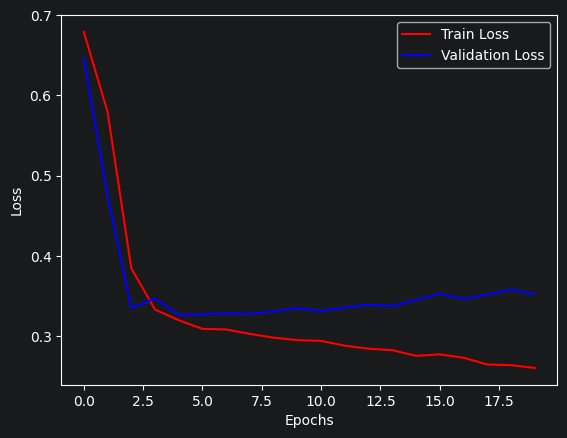


 ===================== Training Fold 1  ===================== 

Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.6452261805534363
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.4885774627327919
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.34081417322158813
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.3375271260738373
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32525772601366043
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32161691039800644
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32079048454761505
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.31881652772426605


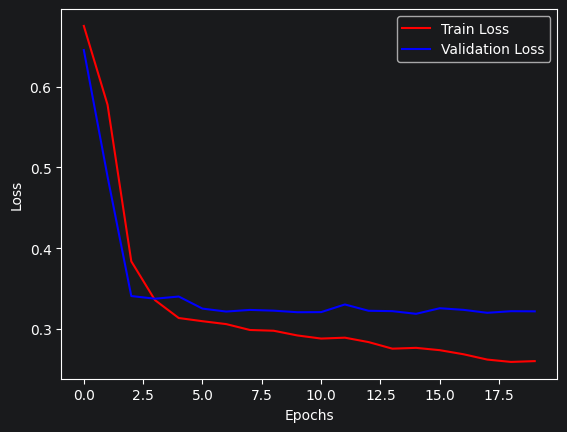


 ===================== Training Fold 2  ===================== 

Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.6447755098342896
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.47328805923461914
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.3354273736476898
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.3347155451774597


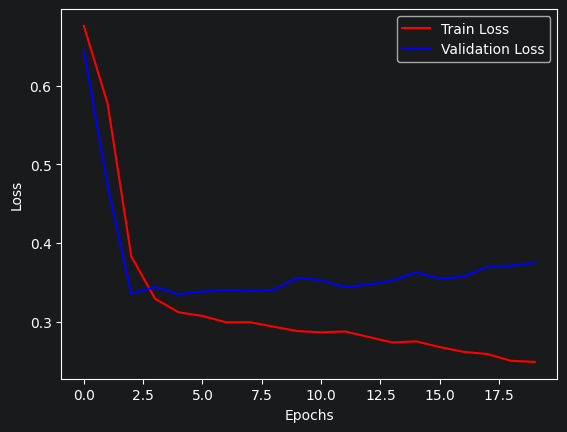


 ===================== Training Fold 3  ===================== 

Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.6690243184566498
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.5416742116212845
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3615354523062706
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3611207976937294
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.35704340785741806
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3469751551747322


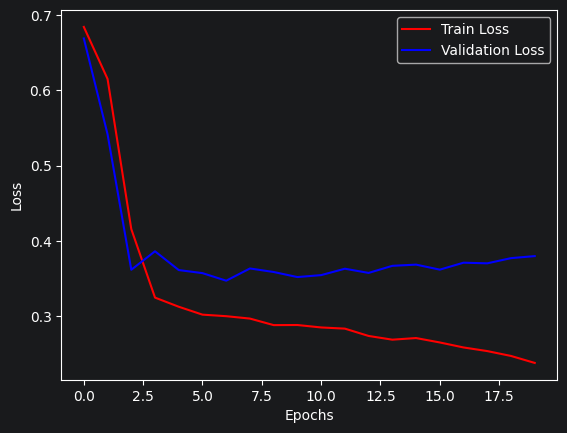


 ===================== Training Fold 4  ===================== 

Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.6502691805362701
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.4908256456255913
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.34098703414201736
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.3254028931260109
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.31902407854795456
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.3189802020788193
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.31788182258605957


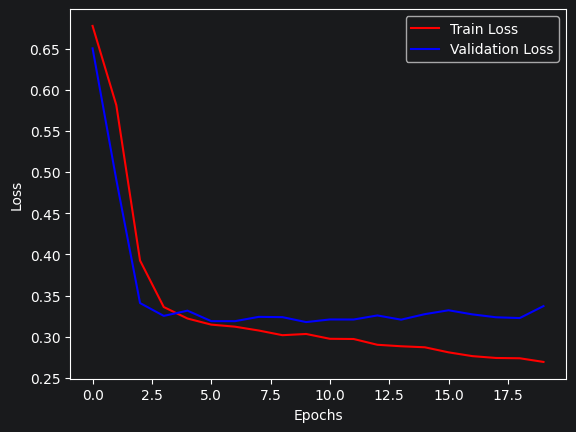

In [26]:
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import os

#paths
write_model_dir = os.path.join('Models', 'no_cal')
os.makedirs(write_model_dir, exist_ok=True)


# Hyperparameter
batch_size = 256
learning_rate = 1e-3 #https://x.com/karpathy/status/801621764144971776?lang=en
n_epochs = 20

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':1
}

# Dataset
trainval_set = TensorDataset(X_train_val_cal, y_train_val_cal)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(trainval_set)))):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')


    # Loaders
    train_loader, val_loader = get_train_loaders(
        dataset=trainval_set,
        train_idx=train_idx,
        val_idx=val_idx,
        batch_size=batch_size,
    )

    # Model, Optimizer, Criterion
    model = MLPClassifier(**model_parameter).to(DEVICE)
    Optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(n_epochs):
        train_loss = _train_one_epoch(model, train_loader, Optimizer, criterion)
        val_loss = _calculate_val_loss(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if best_val_loss > val_loss:
            best_val_loss = val_loss
            model_path = os.path.join(write_model_dir, f"fold_{fold}.pth")
            torch.save(model.state_dict(), model_path)
            print(f'Saved new best model to {model_path}, with new {best_val_loss=}')

    plt.plot(history['train_loss'], label='Train Loss', color='red')
    plt.plot(history['val_loss'], label='Validation Loss', color='blue')
    plt.grid(False)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Calibration

## Temperature Scaler

In [59]:
import torch
from torch import nn

class TemperatureScaler(nn.Module):
    def __init__(self, model):
         super().__init__()
         self.model = model
         model.eval()
         self.temperature = nn.Parameter(torch.ones(1)) # T

    def forward(self, x):
        with torch.no_grad():
            logits = self.model(x)

        return logits / self.temperature

def fit_temperature(model, X_val, y_val):
    scaler = TemperatureScaler(model).to(DEVICE)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=15000)
    criterion = nn.BCEWithLogitsLoss()

    def closure():
        optimizer.zero_grad()
        logits = scaler(X_val)
        loss = criterion(logits, y_val)
        loss.backward()

        return loss

    optimizer.step(closure)
    return scaler

## Training scalers

In [60]:
write_model_dir = os.path.join('Models', 'no_cal')
write_scaler_path = os.path.join('Models', 'scaler')
os.makedirs(write_scaler_path, exist_ok=True)
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':1
}

for idx in range(5):
    print(f'\n ===================== Training Fold {idx}  ===================== \n')

    m = MLPClassifier(**model_parameter).to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(write_model_dir, f"fold_{idx}.pth")))

    scaler = fit_temperature(m, X_cal.to(DEVICE), y_cal.to(DEVICE))
    scaler_path = os.path.join(write_scaler_path, f"fold_{idx}.pth")
    torch.save(scaler.state_dict(), scaler_path)




 ===================== Training Fold 0  ===================== 


 ===================== Training Fold 1  ===================== 


 ===================== Training Fold 2  ===================== 


 ===================== Training Fold 3  ===================== 


 ===================== Training Fold 4  ===================== 



# Results

## Prediction

In [76]:
import torch.nn.functional as F
import torch

write_model_dir = os.path.join('Models', 'no_cal')
write_scaler_path = os.path.join('Models', 'scaler')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
probs = {
    'before':[],
    'after':[]
}

for idx in range(5):
    m = MLPClassifier(**model_parameter).to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(write_model_dir, f"fold_{idx}.pth")))

    scaler = TemperatureScaler(m).to(DEVICE)
    scaler.load_state_dict(torch.load(os.path.join(write_scaler_path, f"fold_{idx}.pth")))


    # Before calibration
    logits = m(X_test.to(DEVICE)).detach()
    probs_before = torch.sigmoid(logits).cpu().numpy()

    # After temperature scaling
    logits_scaled = scaler(X_test.to(DEVICE)).detach()
    probs_after = torch.sigmoid(logits_scaled).cpu().numpy()

    probs['before'].append(probs_before)
    probs['after'].append(probs_after)

## Calibration Plots and Brier Score

Fold_0
Brier Score before Calibration: 0.11104906093205366
Brier Score After Calibration: 0.11140179803606268


Fold_1
Brier Score before Calibration: 0.10586238865972035
Brier Score After Calibration: 0.1065239439507022


Fold_2
Brier Score before Calibration: 0.10391155886180702
Brier Score After Calibration: 0.10406160891218283


Fold_3
Brier Score before Calibration: 0.10719299991423509
Brier Score After Calibration: 0.1073139130481851


Fold_4
Brier Score before Calibration: 0.10659683168595367
Brier Score After Calibration: 0.10664418363355349




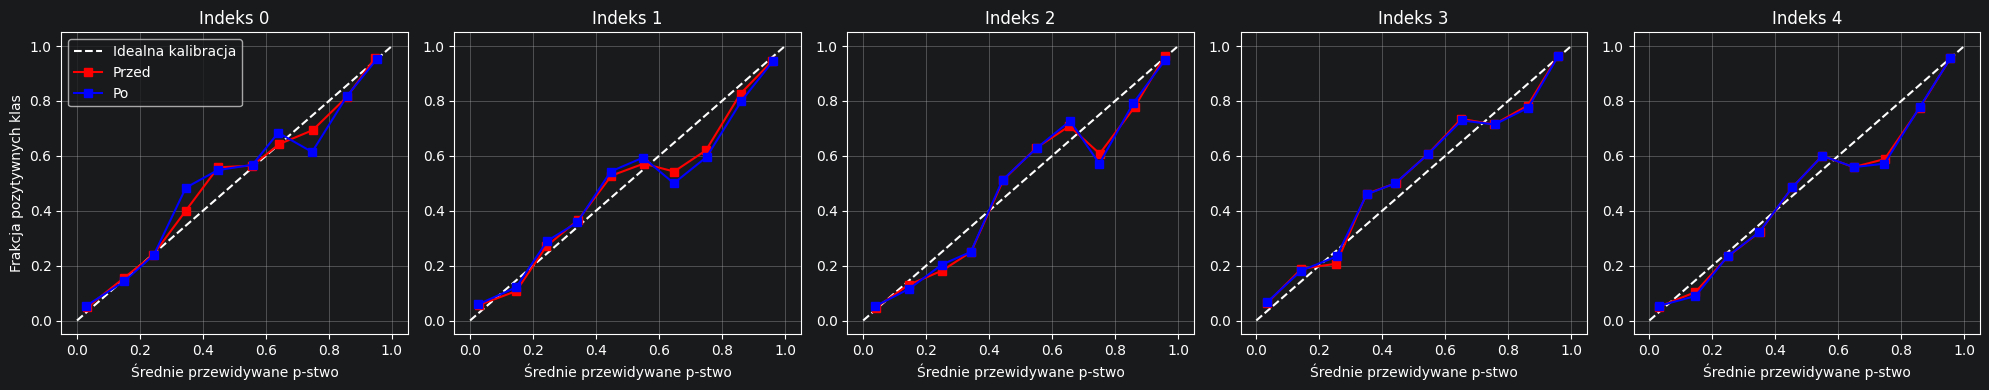

In [77]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt

brier = []
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx in range(5):
    probs_before = probs['before'][idx]
    probs_after = probs['after'][idx]

    # Calibration Curves
    frac_pos_before, mean_pred_before = calibration_curve(
     y_test, probs_before, n_bins=10
    )

    frac_pos_after, mean_pred_after = calibration_curve(
     y_test, probs_after, n_bins=10
    )

    # Brier Score
    b_before = brier_score_loss(y_test, probs_before)
    b_after = brier_score_loss(y_test, probs_after)
    print(f'Fold_{idx}\n'
        f'Brier Score before Calibration: {b_before}\n'
        f'Brier Score After Calibration: {b_after}\n\n')

    ax = axes[idx]


    ax.plot([0, 1], [0, 1], "w--", label="Idealna kalibracja")
    ax.plot(mean_pred_before, frac_pos_before, "s-", color="red", label="Przed")
    ax.plot(mean_pred_after, frac_pos_after, "s-", color="blue", label="Po")

    ax.set_title(f"Indeks {idx}")
    ax.set_xlabel("Średnie przewidywane p-stwo")
    if idx == 0:
        ax.set_ylabel("Frakcja pozytywnych klas")
        ax.legend(loc="upper left")
    ax.grid(True)



plt.tight_layout()
plt.show()